In [1]:
""" ПОсмотрим как метод TAM поможет нам на задаче определения светофоров на дорожных снимках"""

' ПОсмотрим как метод TAM поможет нам на задаче определения светофоров на дорожных снимках'

In [2]:
import os
import sys
import numpy as np
import torch
import cv2
from PIL import Image
import matplotlib.pyplot as plt

assert torch.cuda.is_available(), "CUDA not available"
print(f"PyTorch: {torch.__version__}, CUDA: {torch.version.cuda}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch: 2.10.0+cu128, CUDA: 12.8
GPU: Tesla T4


In [3]:
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
import torch

MODEL_NAME = "Qwen/Qwen2-VL-2B-Instruct"

dtype = torch.float16 if torch.cuda.get_device_properties(0).total_memory < 16e9 else torch.bfloat16

processor = AutoProcessor.from_pretrained(MODEL_NAME)
model = Qwen2VLForConditionalGeneration.from_pretrained(
    MODEL_NAME,
    torch_dtype=dtype,
    device_map="auto",
    low_cpu_mem_usage=True
)

print(f"Model loaded: {model.__class__.__name__}")
print(f"Device: {next(model.parameters()).device}, Dtype: {next(model.parameters()).dtype}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/347 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/272 [00:00<?, ?B/s]

Model loaded: Qwen2VLForConditionalGeneration
Device: cuda:0, Dtype: torch.float16


In [18]:
import os
import requests
from PIL import Image
from io import BytesIO

DATA_DIR = "data/traffic_lights"
os.makedirs(DATA_DIR, exist_ok=True)

# Проверенные прямые ссылки (Wikimedia + другие источники)
IMG_URLS = [
    # 1. Классический светофор в Лондоне (арт-объект, но видно хорошо)
    "https://upload.wikimedia.org/wikipedia/commons/1/15/London_traffic-lights.JPG",
    # 2. Светофор на сельской дороге в Великобритании
    "https://upload.wikimedia.org/wikipedia/commons/b/b2/-2022-02-10_Traffic_lights_in_Church_Street%2C_Trimingham%2C_Norfolk_%282%29.jpg",
    # 3. Светофор в Пензе (Россия)
    "https://upload.wikimedia.org/wikipedia/commons/e/ed/%D0%A1%D0%B2%D0%B5%D1%82%D0%BE%D1%84%D0%BE%D1%80_%D0%B2_%D0%9F%D0%B5%D0%BD%D0%B7%D0%B5.jpg",
    # 4. Светофор Т-7 на трассе Р-21 «Кола» (Россия)
    "https://upload.wikimedia.org/wikipedia/commons/5/5b/%D0%A1%D0%B2%D0%B5%D1%82%D0%BE%D1%84%D0%BE%D1%80_%D0%A2-7_%D0%BD%D0%B0_%D0%A0_21_%D0%9A%D0%BE%D0%BB%D0%B0.jpg"
]

headers = {
    "User-Agent": "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36",
    "Accept": "image/*,*/*;q=0.8",
    "Accept-Encoding": "gzip, deflate",
    "Connection": "keep-alive"
}

img_paths = []
for i, url in enumerate(IMG_URLS):
    fpath = os.path.join(DATA_DIR, f"tl_{i}.jpg")
    try:
        resp = requests.get(url, headers=headers, timeout=20, allow_redirects=True)
        resp.raise_for_status()
        img = Image.open(BytesIO(resp.content)).convert("RGB")
        img.save(fpath)
        img_paths.append(fpath)
        print(f"✓ {i+1}: {fpath} ({img.size})")
    except Exception as e:
        print(f"✗ {i+1}: {e}")

# [CHECK]
assert len(img_paths) >= 1, "Не удалось скачать ни одного изображения"
imgs = [Image.open(p) for p in img_paths]
print(f"\nLoaded: {len(imgs)} image(s). Sizes: {[im.size for im in imgs]}")

✓ 1: data/traffic_lights/tl_0.jpg ((1920, 2560))
✗ 2: 404 Client Error: Not Found for url: https://upload.wikimedia.org/wikipedia/commons/b/b2/-2022-02-10_Traffic_lights_in_Church_Street%2C_Trimingham%2C_Norfolk_%282%29.jpg
✓ 3: data/traffic_lights/tl_2.jpg ((3000, 1987))
✗ 4: 404 Client Error: Not Found for url: https://upload.wikimedia.org/wikipedia/commons/5/5b/%D0%A1%D0%B2%D0%B5%D1%82%D0%BE%D1%84%D0%BE%D1%80_%D0%A2-7_%D0%BD%D0%B0_%D0%A0_21_%D0%9A%D0%BE%D0%BB%D0%B0.jpg

Loaded: 2 image(s). Sizes: [(1920, 2560), (3000, 1987)]


In [20]:
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
import torch

# Промпт для задачи анализа светофоров
PROMPT = "Describe the traffic lights in this image: their state (red/yellow/green), position, and any notable details."

def prepare_input(image, processor, prompt, max_length=512):
    """Подготовка входа для Qwen2-VL"""
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": prompt}
            ]
        }
    ]
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = processor(
        images=[image],
        text=text,
        return_tensors="pt",
        padding=True
    )
    return inputs

# [CHECK]
test_input = prepare_input(imgs[1], processor, PROMPT)
print(f"Input keys: {list(test_input.keys())}")
print(f"Input IDs shape: {test_input['input_ids'].shape}")
print(f"Pixel values shape: {test_input['pixel_values'].shape if 'pixel_values' in test_input else 'N/A'}")
assert 'input_ids' in test_input, "Missing input_ids"

Input keys: ['input_ids', 'attention_mask', 'pixel_values', 'image_grid_thw']
Input IDs shape: torch.Size([1, 7642])
Pixel values shape: torch.Size([30388, 1176])


In [6]:
model.eval()

def generate_with_hidden_states(model, inputs, device, max_new_tokens=128):
    """Генерация ответа с сохранением hidden_states для каждого шага"""
    inputs = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in inputs.items()}

    with torch.no_grad():
        # Первый проход: получить ответ
        output = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            output_hidden_states=True,
            return_dict_in_generate=True,
            pad_token_id=processor.tokenizer.pad_token_id
        )

    return output

In [21]:
device = next(model.parameters()).device
output = generate_with_hidden_states(model, test_input, device, max_new_tokens=64)

generated_ids = output.sequences[0, test_input['input_ids'].shape[1]:]
generated_text = processor.decode(generated_ids, skip_special_tokens=True)
print(f"Generated: {generated_text[:200]}...")
print(f"Hidden states layers: {len(output.hidden_states)}")
print(f"Last layer shape: {output.hidden_states[-1][0].shape}")

Generated: The traffic lights in the image are green. They are positioned on a pole, with the green light illuminated. The lights are arranged in a typical traffic light configuration, with the red light on the ...
Hidden states layers: 62
Last layer shape: torch.Size([1, 1, 1536])


In [22]:
import torch
import torch.nn.functional as F

def compute_tam_activations(model, inputs, generated_ids, device):
    model.eval()
    inputs = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)
        last_hidden = outputs.hidden_states[-1][0]  # [seq_len, hidden_dim]
        seq_len = last_hidden.shape[0]

        # Безопасная оценка количества визуальных токенов
        n_vis_raw = inputs['pixel_values'].shape[0]
        n_vis = min(n_vis_raw, seq_len // 2)  # Консервативная верхняя граница

        # В Qwen2-VL визуальные эмбеддинги идут в начале последовательности
        visual_embeds = last_hidden[:n_vis]
        text_start = n_vis

        tam_maps = []
        for token_idx in range(len(generated_ids)):
            idx = text_start + token_idx
            if idx >= seq_len:
                break
            token_hidden = last_hidden[idx]
            sim = F.cosine_similarity(token_hidden.unsqueeze(0), visual_embeds, dim=-1)
            tam_maps.append(sim.cpu())

    return tam_maps, n_vis, seq_len

# [CHECK]
generated_ids = output.sequences[0, test_input['input_ids'].shape[1]:]
tam_maps, n_vis_used, seq_len = compute_tam_activations(model, test_input, generated_ids[:5], device)
print(f"Sequence length: {seq_len}, Visual tokens used: {n_vis_used}")
print(f"TAM maps computed: {len(tam_maps)}")
if tam_maps:
    print(f"Map range: [{tam_maps[0].min():.3f}, {tam_maps[0].max():.3f}]")
assert len(tam_maps) > 0, "TAM computation failed"

Sequence length: 7642, Visual tokens used: 3821
TAM maps computed: 5
Map range: [-0.192, 0.868]


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import matplotlib.cm as cm

def visualize_tam_contrast(image, tam_activations, n_vis, contrast_boost=2.0):
    """
    Визуализация TAM с повышенной контрастностью.
    contrast_boost > 1 усиливает разницу между высокими и низкими активациями.
    """
    img_w, img_h = image.size
    aspect = img_w / img_h
    grid_h = int(np.sqrt(n_vis / aspect))
    grid_w = int(n_vis / grid_h)

    act = tam_activations.numpy().astype(np.float32)
    if len(act) > grid_h * grid_w:
        act = act[:grid_h * grid_w]
    elif len(act) < grid_h * grid_w:
        act = np.pad(act, (0, grid_h * grid_w - len(act)), mode='constant')

    heatmap_2d = act.reshape(grid_h, grid_w)
    heatmap = np.array(Image.fromarray(heatmap_2d, mode='F').resize(
        (img_w, img_h), resample=Image.BILINEAR))

    # Контрастное усиление через центрирование и масштабирование
    hm_mean = heatmap.mean()
    hm_std = heatmap.std() + 1e-6
    hm_enhanced = (heatmap - hm_mean) / hm_std * contrast_boost + 0.5
    hm_norm = np.clip(hm_enhanced, 0, 1)

    # Применяем colormap с высокой контрастностью
    cmap = cm.get_cmap('jet')
    hm_colored = cmap(hm_norm)[..., :3] * 255  # RGB

    # Alpha blending: прозрачность зависит от силы активации
    alpha_map = np.clip(hm_norm * 0.9, 0.1, 0.85)
    overlay = np.array(image).copy().astype(float)

    for c in range(3):
        overlay[:, :, c] = np.clip(
            overlay[:, :, c] * (1 - alpha_map) + hm_colored[:, :, c] * alpha_map,
            0, 255
        )

    return overlay.astype(np.uint8), hm_norm, hm_colored.astype(np.uint8)

# [CHECK]
overlay_contrast, hm_norm, hm_rgb = visualize_tam_contrast(imgs[0], tam_maps[0], n_vis_used, contrast_boost=2.5)
print(f"Contrast overlay shape: {overlay_contrast.shape}")
print(f"Normalized heatmap range: [{hm_norm.min():.3f}, {hm_norm.max():.3f}]")
assert overlay_contrast.shape[:2] == imgs[0].size[::-1], "Size mismatch"

/tmp/ipykernel_2784/3651518689.py:23: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  heatmap = np.array(Image.fromarray(heatmap_2d, mode='F').resize(
/tmp/ipykernel_2784/3651518689.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('jet')


Contrast overlay shape: (2560, 1920, 3)
Normalized heatmap range: [0.000, 1.000]


/tmp/ipykernel_2784/3651518689.py:23: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  heatmap = np.array(Image.fromarray(heatmap_2d, mode='F').resize(
/tmp/ipykernel_2784/3651518689.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('jet')


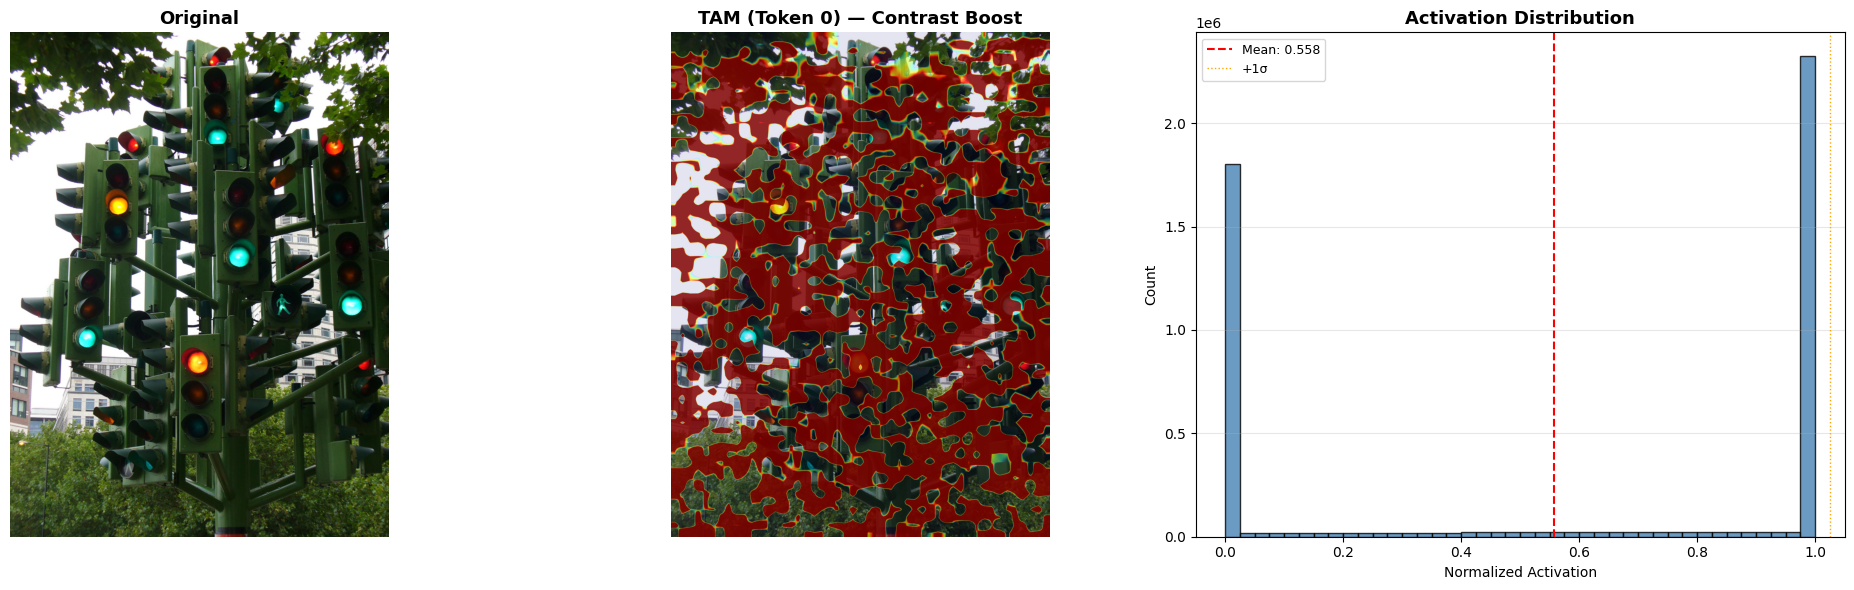


Model output (first 200 chars):
The traffic lights in the image are arranged in a complex, multi-level structure. Here are the details:

1. **Red Lights**: 
   - The topmost level has three red lights.
   - The middle level has two ...


In [24]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

def show_tam_contrast(image, overlay, hm_norm, generated_text, token_idx=0):
    """Показывает оригинал, контрастный TAM и гистограмму активаций"""
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # 1. Оригинал
    axes[0].imshow(image)
    axes[0].set_title("Original", fontsize=13, fontweight='bold')
    axes[0].axis('off')

    # 2. TAM с контрастным оверлеем
    axes[1].imshow(overlay)
    axes[1].set_title(f"TAM (Token {token_idx}) — Contrast Boost", fontsize=13, fontweight='bold')
    axes[1].axis('off')

    # 3. Гистограмма + статистика
    vals = hm_norm.flatten()
    axes[2].hist(vals, bins=40, color='steelblue', edgecolor='black', alpha=0.8)
    axes[2].axvline(vals.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {vals.mean():.3f}')
    axes[2].axvline(vals.mean() + vals.std(), color='orange', linestyle=':', linewidth=1, label=f'+1σ')
    axes[2].set_title("Activation Distribution", fontsize=13, fontweight='bold')
    axes[2].set_xlabel("Normalized Activation")
    axes[2].set_ylabel("Count")
    axes[2].legend(fontsize=9)
    axes[2].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Текст ответа модели
    print(f"\nModel output (first 200 chars):\n{generated_text[:200]}...")

# Инференс + TAM для первого изображения
test_input = prepare_input(imgs[0], processor, PROMPT)
output = generate_with_hidden_states(model, test_input, device, max_new_tokens=128)
generated_ids = output.sequences[0, test_input['input_ids'].shape[1]:]
generated_text = processor.decode(generated_ids, skip_special_tokens=True)

tam_maps, n_vis, _ = compute_tam_activations(model, test_input, generated_ids[:3], device)
overlay_c, hm_n, _ = visualize_tam_contrast(imgs[0], tam_maps[0], n_vis, contrast_boost=2.5)

show_tam_contrast(imgs[0], overlay_c, hm_n, generated_text, token_idx=0)

In [25]:
""" Потыкали в TAM, мне вообще интересно было куда смотрять современные VL-ки, когда отвечают

Да, конечно, может моделька маленькая, я бы такой не дал бы пока управлять машиной со мной,
но вообще такой метод надо брать на вооружение чтобы интерпретировать действия модели, потому что они
часто ведут себя непредсказуемо"""

' Потыкали в TAM, мне вообще интересно было куда смотрять современные VL-ки, когда отвечают\n\nДа, конечно, может моделька маленькая, я бы такой не дал бы пока управлять машиной со мной, \nно вообще такой метод надо брать на вооружение чтобы интерпретировать действия модели, потому что они \nчасто ведут себя непредсказуемо'